# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [1]:
# Import essential libraries for data manipulation and analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_columns',None)


## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [2]:
# Importing the file porter_data_1.csv
df = pd.read_csv('/Users/prashanthi/Downloads/Delivery_Starter/porter_data_1.csv')
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,distance
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,34.44
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,27.60
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,11.56
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,31.80
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,8.20


## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [3]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['created_hour'] = df['created_at'].dt.hour
df['created_dayofweek'] = df['created_at'].dt.dayofweek

##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [8]:
# Convert categorical features to category type
df.dtypes


market_id                          float64
created_at                  datetime64[ns]
actual_delivery_time                object
store_primary_category               int64
order_protocol                     float64
total_items                          int64
subtotal                             int64
num_distinct_items                   int64
min_item_price                       int64
max_item_price                       int64
total_onshift_dashers              float64
total_busy_dashers                 float64
total_outstanding_orders           float64
distance                           float64
created_hour                         int32
created_dayofweek                    int32
dtype: object

#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [11]:
# Calculate time taken in minutes
# Ensure both are datetime columns
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'], errors='coerce')

# Then compute the delivery time in minutes
df['delivery_time_minutes'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds() / 60

##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [13]:
# Extract the hour and day of week from the 'created_at' timestamp
df['created_hour'] = df['created_at'].dt.hour
df['created_dayofweek'] = df['created_at'].dt.dayofweek

In [8]:
# Drop unnecessary columns


#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [17]:
# Define target variable (y) and features (X)
y = df['delivery_time_minutes']  # or another target column you’re predicting
X = df.drop(columns=['delivery_time_minutes', 'actual_delivery_time', 'created_at'])  # drop target and datetime columns

##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [18]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


In [19]:
# Define numerical and categorical columns for easy EDA and data manipulation

numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

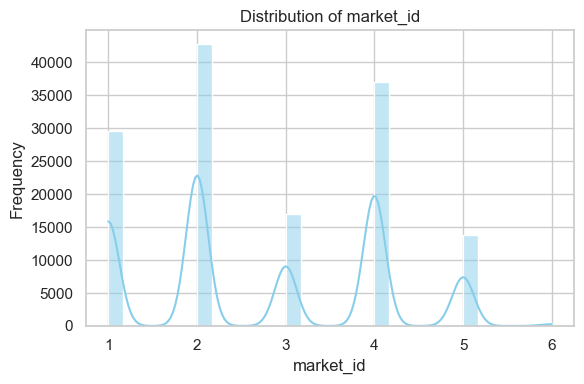

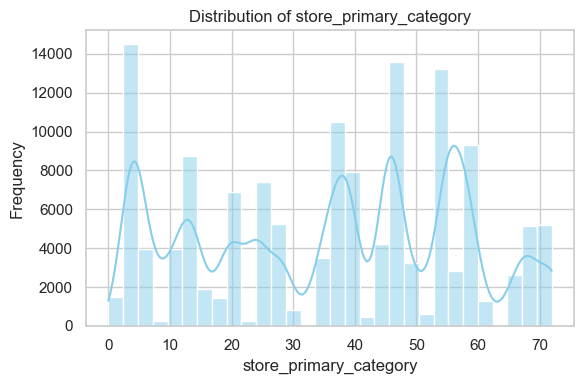

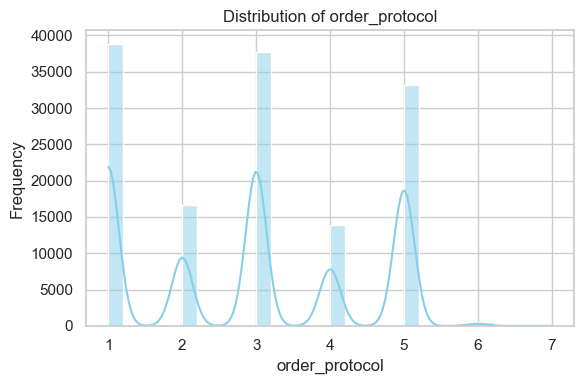

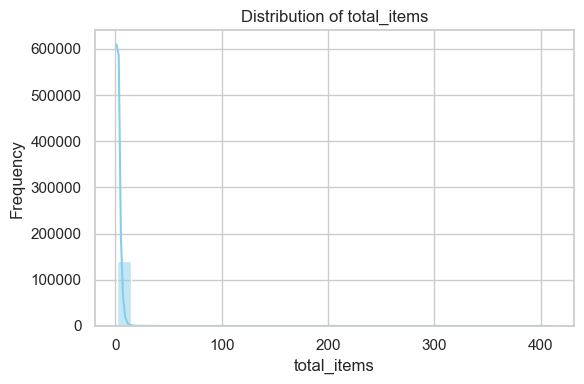

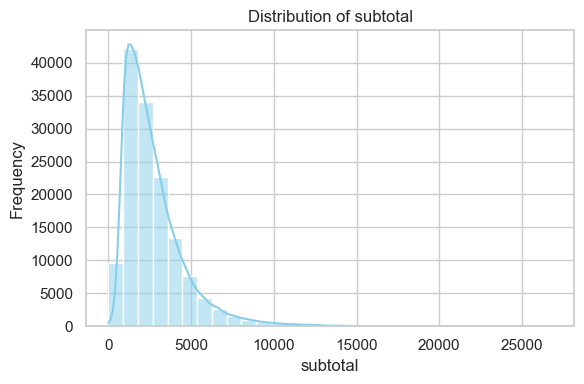

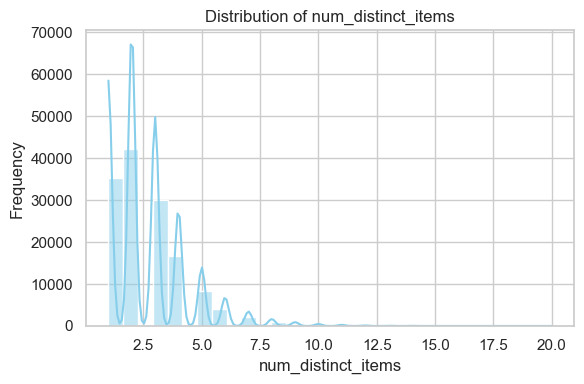

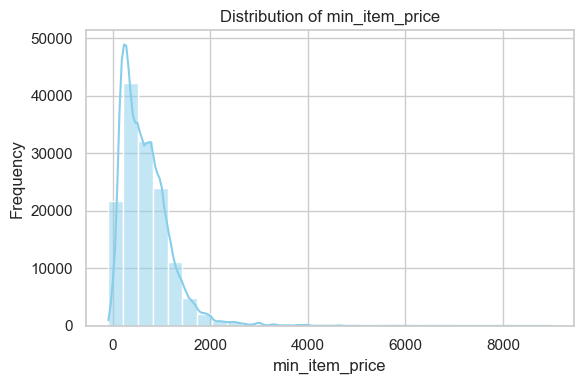

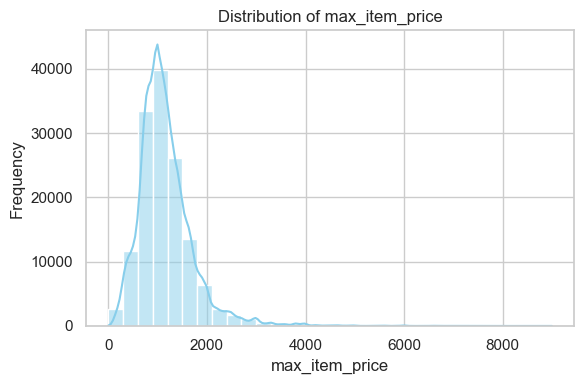

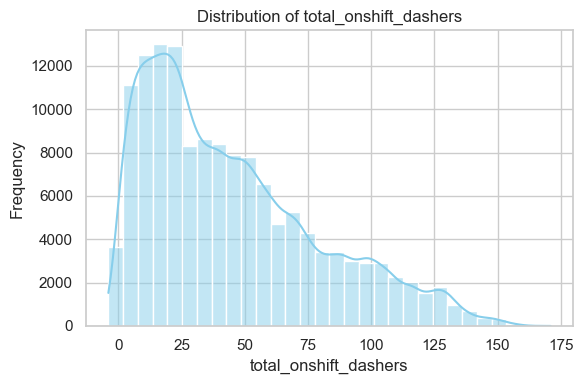

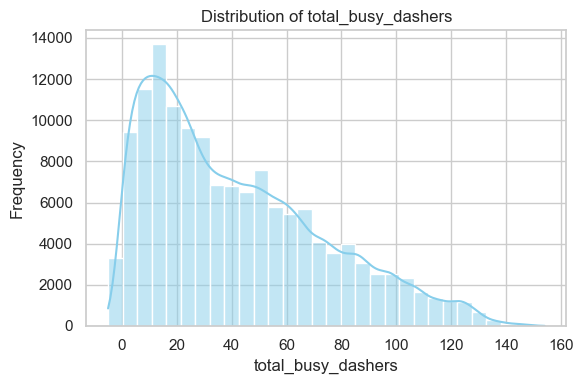

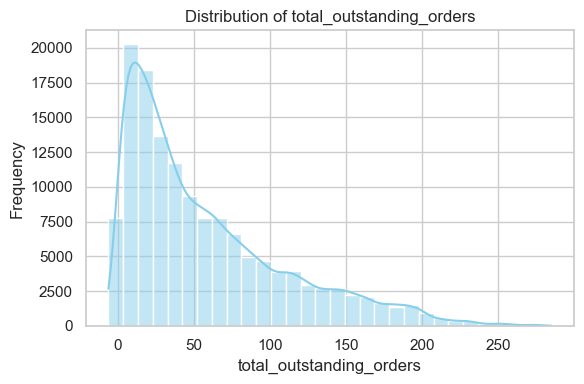

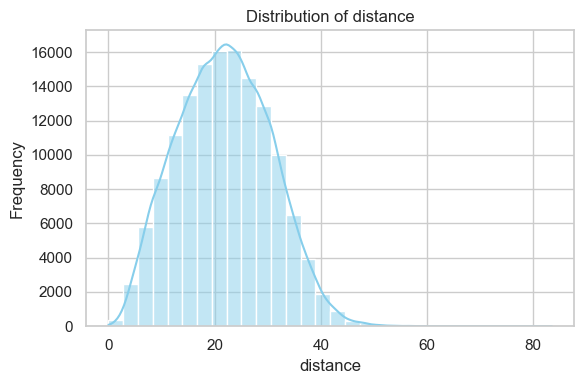

In [20]:
# Plot distributions for all numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")

# Plot distributions
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(X_train[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features

In [21]:
# Distribution of categorical columns
# Plot distributions of categorical columns
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=X_train, x=col, order=X_train[col].value_counts().index, palette='Set2')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

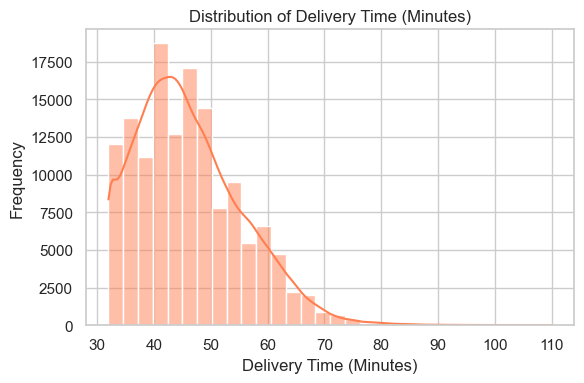

In [22]:
# Distribution of time_taken
plt.figure(figsize=(6, 4))
sns.histplot(y_train, bins=30, kde=True, color='coral')
plt.title("Distribution of Delivery Time (Minutes)")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

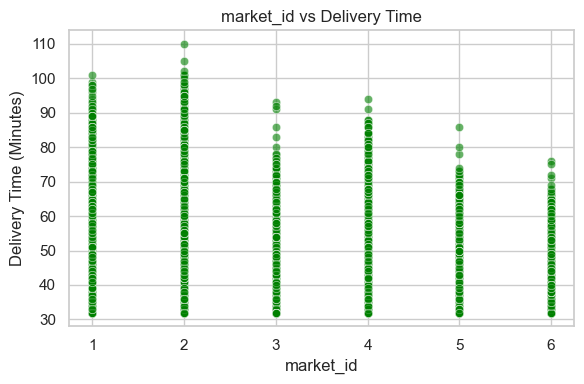

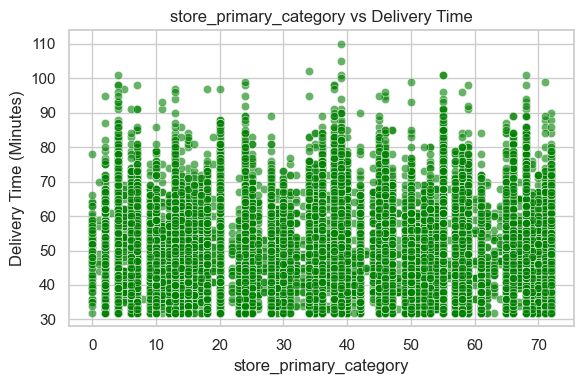

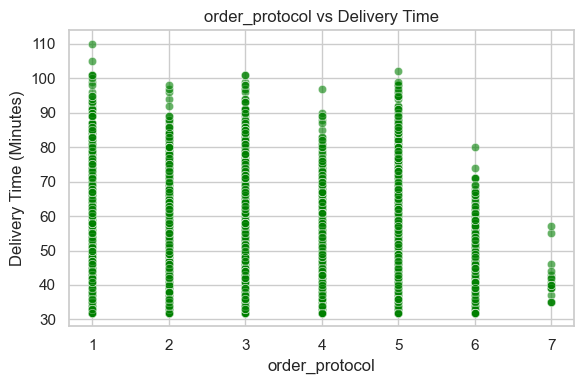

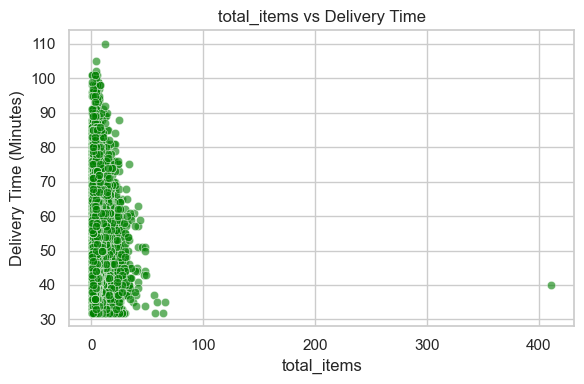

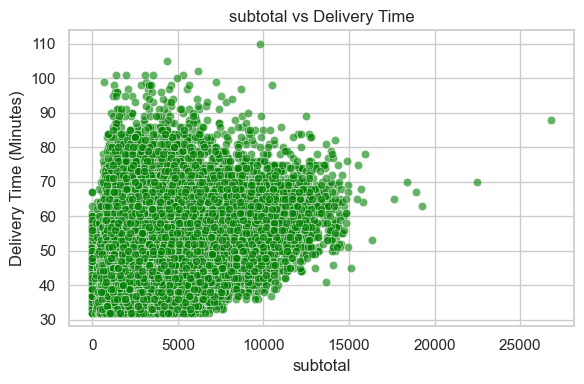

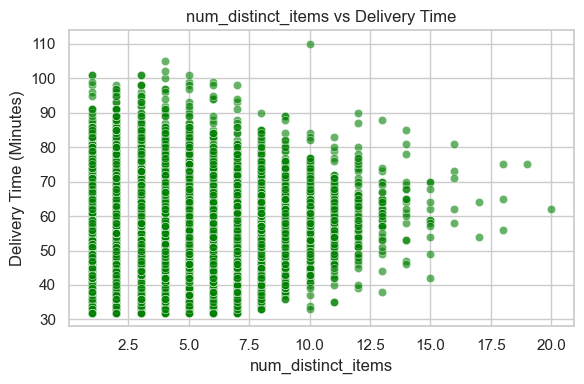

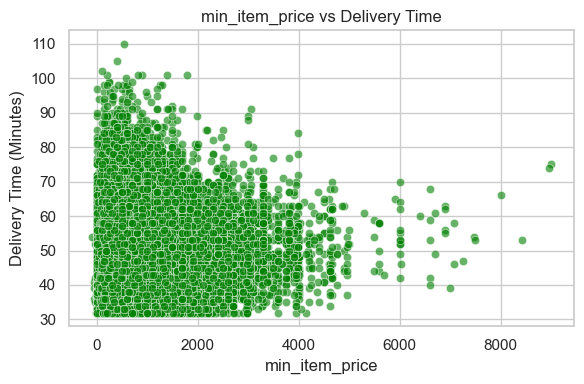

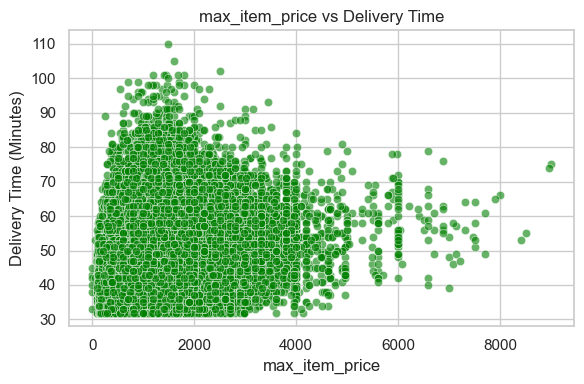

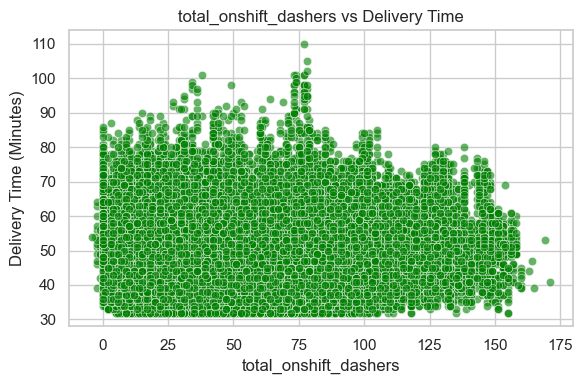

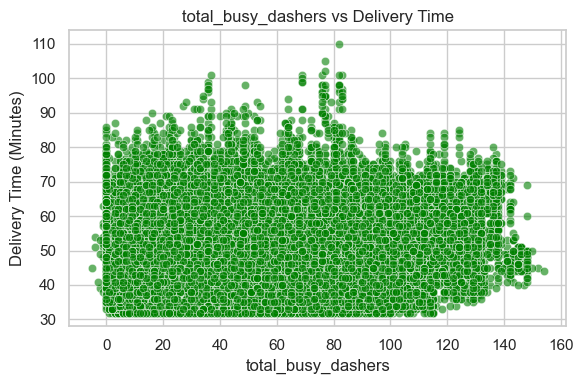

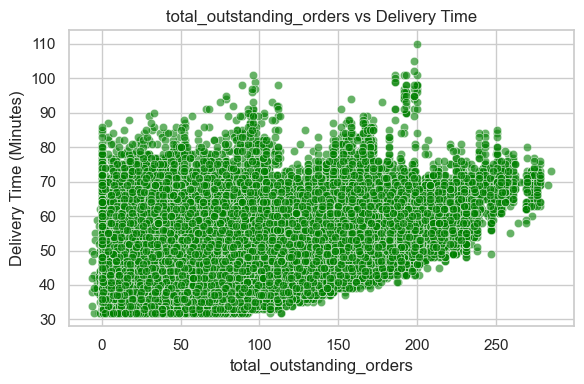

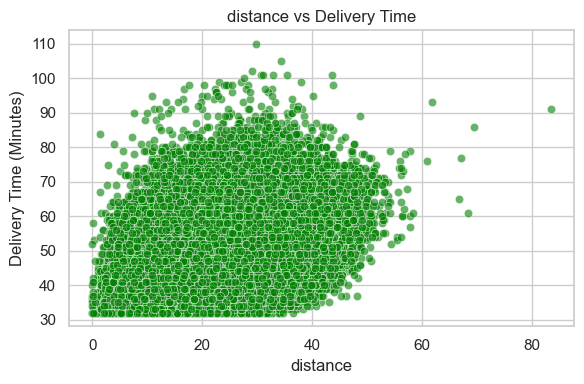

/var/folders/h7/b61d52nd0n13mhlvz1sjbwpm0000gn/T/ipykernel_36473/3326866112.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['created_hour'], y=df['delivery_time_minutes'], palette='coolwarm')


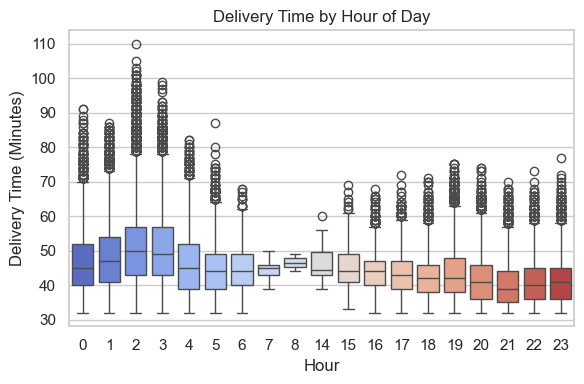

In [24]:
# Scatter plot to visualise the relationship between time_taken and other features
# Scatter plots of numerical features vs delivery time
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_train[col], y=y_train, color='green', alpha=0.6)
    plt.title(f'{col} vs Delivery Time')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (Minutes)')
    plt.tight_layout()
    plt.show()



/var/folders/h7/b61d52nd0n13mhlvz1sjbwpm0000gn/T/ipykernel_36473/629055960.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df['created_hour'], y=df['delivery_time_minutes'], palette='coolwarm')


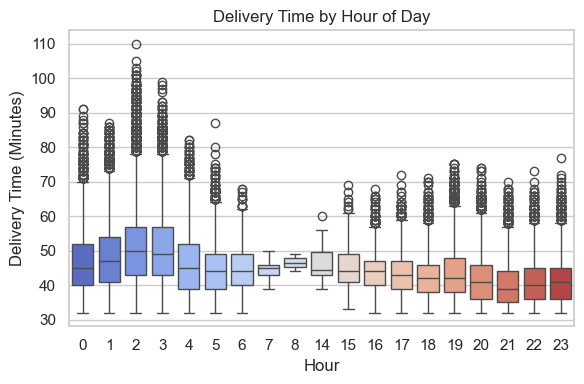

In [26]:
# Show the distribution of time_taken for different hours

# Delivery time by hour of day
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['created_hour'], y=df['delivery_time_minutes'], palette='coolwarm')
plt.title("Delivery Time by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Delivery Time (Minutes)")
plt.tight_layout()
plt.show()


#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

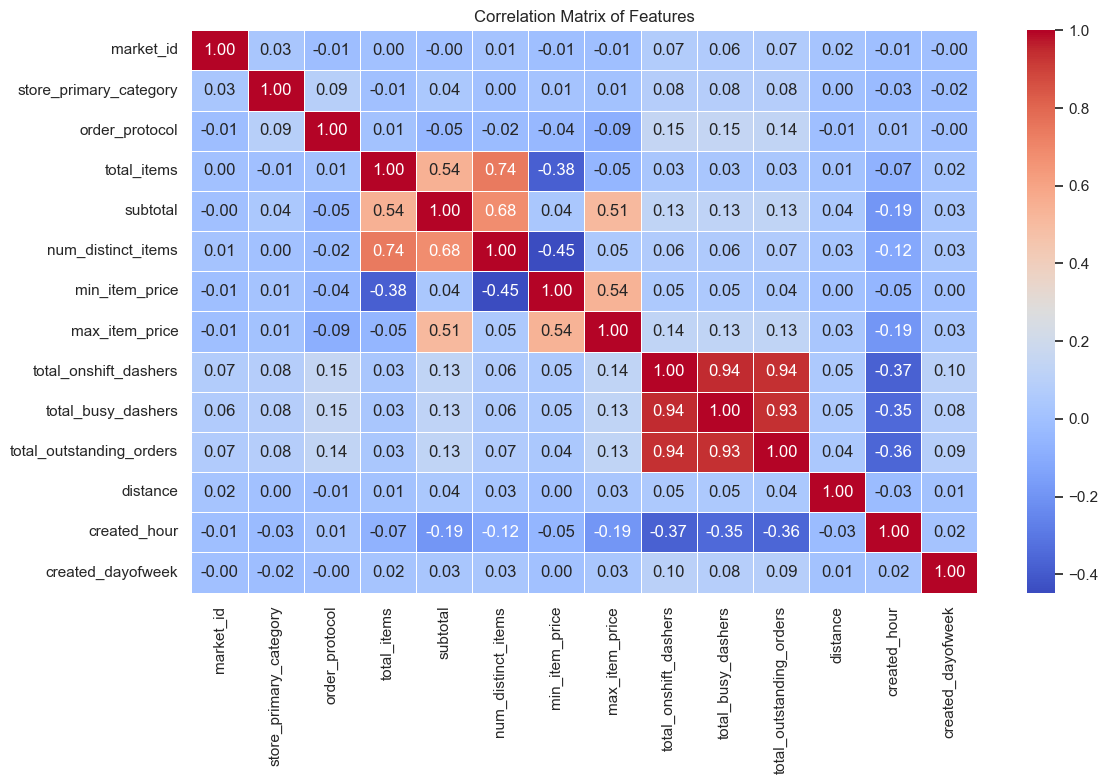

In [27]:
# Plot the heatmap of the correlation matrix
# Calculate correlation matrix
corr_matrix = X_train.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()


##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [28]:
# Drop 3-5 weakly correlated columns from training dataset
# Add target back temporarily to X_train to compute correlation with target
temp = X_train.copy()
temp['delivery_time_minutes'] = y_train

# Correlation with target
target_corr = temp.corr()['delivery_time_minutes'].drop('delivery_time_minutes')
weak_corr_features = target_corr[abs(target_corr) < 0.05].index.tolist()  # you can adjust threshold

# Drop them from feature set
X_train = X_train.drop(columns=weak_corr_features)
X_test = X_test.drop(columns=weak_corr_features)


#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

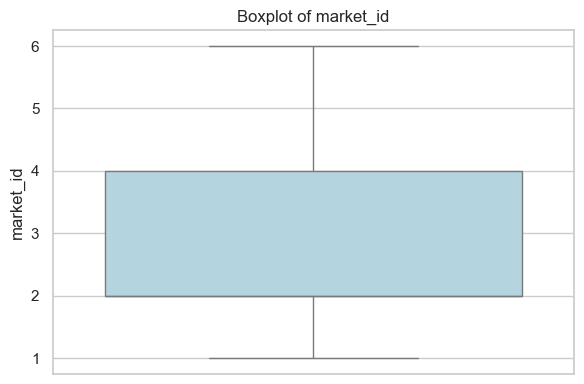

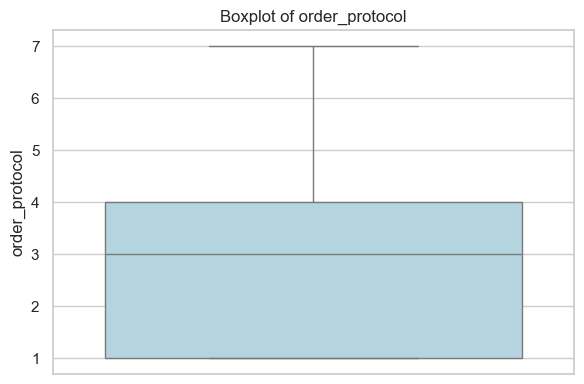

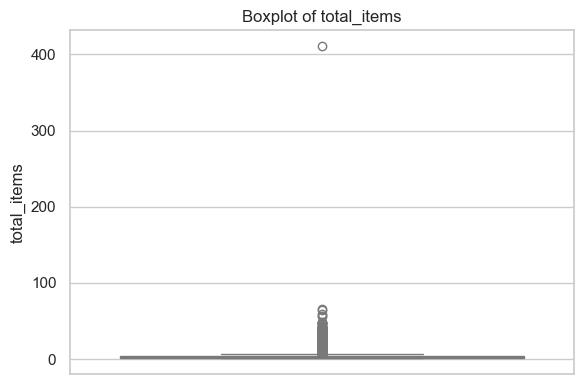

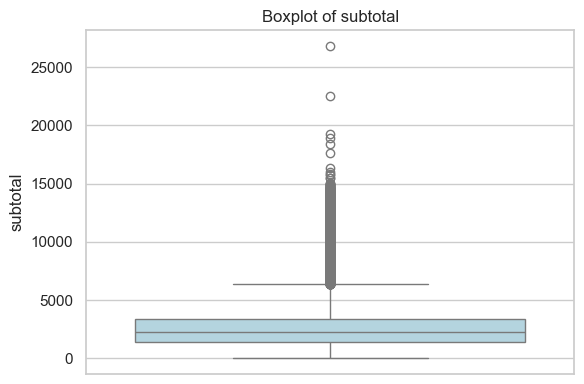

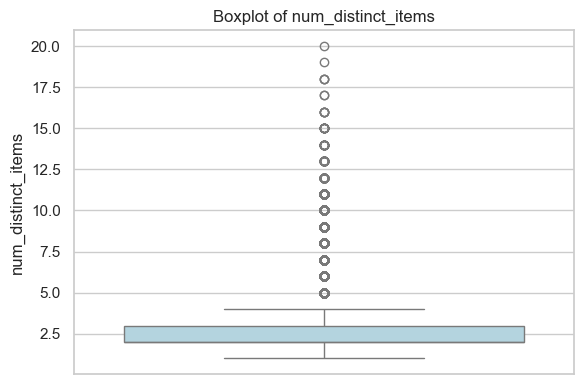

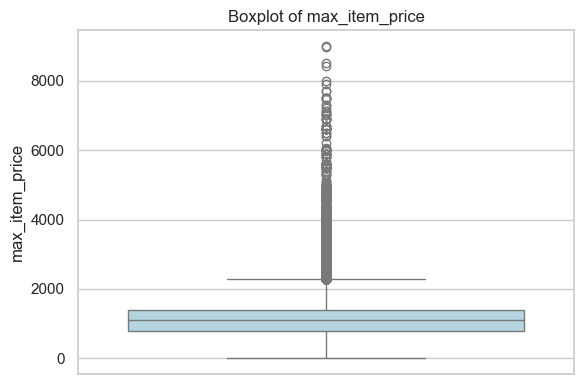

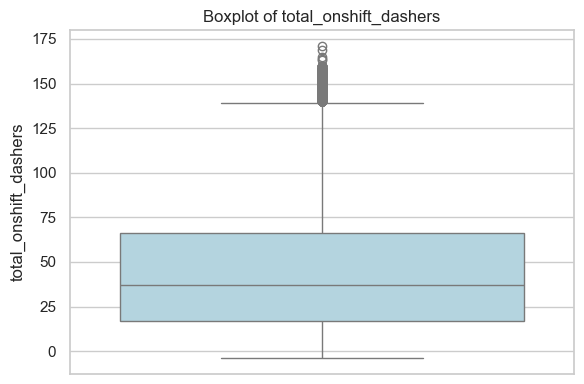

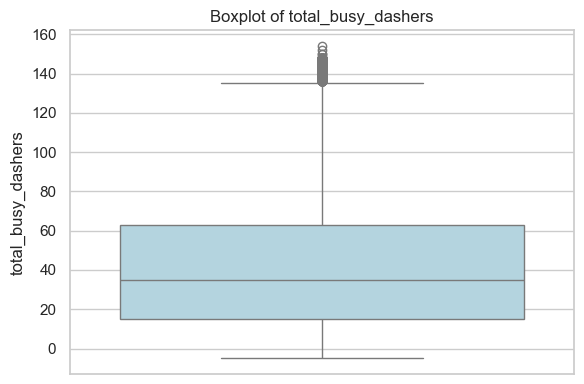

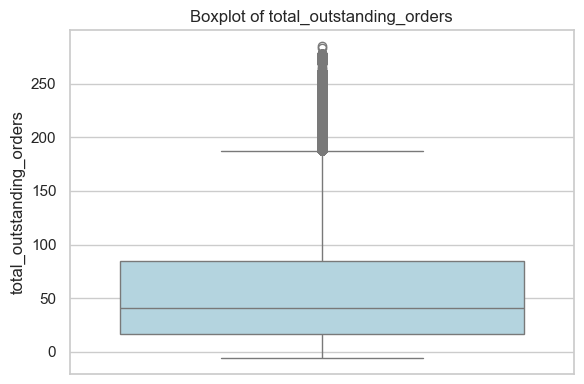

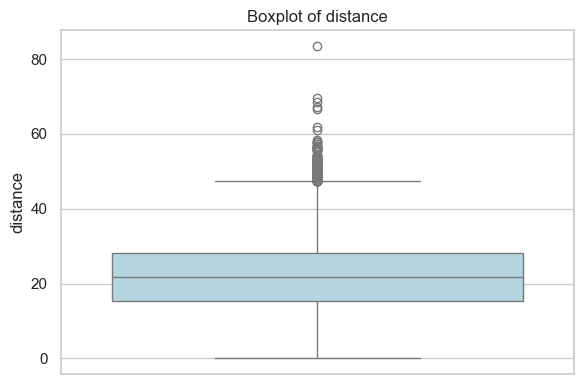

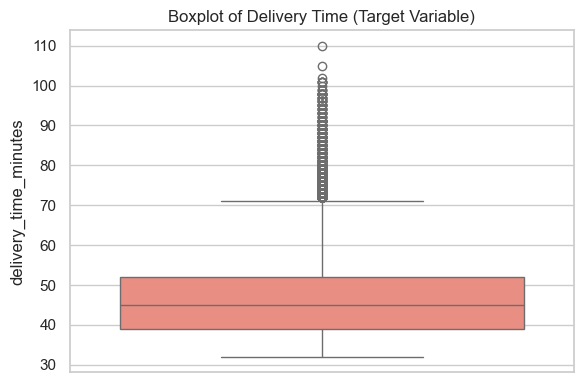

In [29]:
# Boxplot for time_taken
# Boxplots for numerical features
for col in X_train.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=X_train[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()
plt.figure(figsize=(6, 4))
sns.boxplot(y=y_train, color='salmon')
plt.title("Boxplot of Delivery Time (Target Variable)")
plt.tight_layout()
plt.show()

##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [30]:
# Handle outliers
# Define a function to remove outliers using IQR
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Join X_train and y_train
train_data = X_train.copy()
train_data['delivery_time_minutes'] = y_train

# List of numerical columns (can reuse your previous list)
numerical_cols = train_data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove outliers
train_data_cleaned = remove_outliers_iqr(train_data, numerical_cols)

# Separate back into X and y
y_train = train_data_cleaned['delivery_time_minutes']
X_train = train_data_cleaned.drop(columns=['delivery_time_minutes'])


## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

In [31]:
# Define numerical and categorical columns for easy EDA and data manipulation
numerical_cols_val = X_test.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_val = X_test.select_dtypes(include=['object', 'category']).columns.tolist()


#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

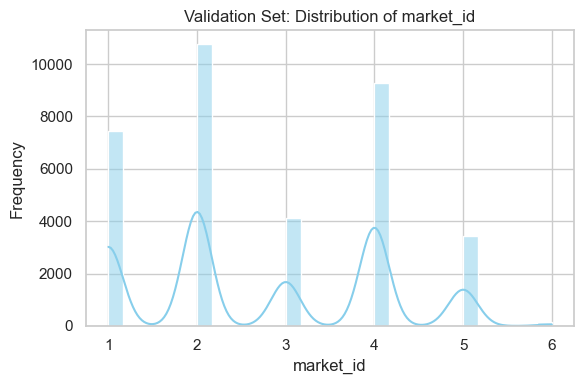

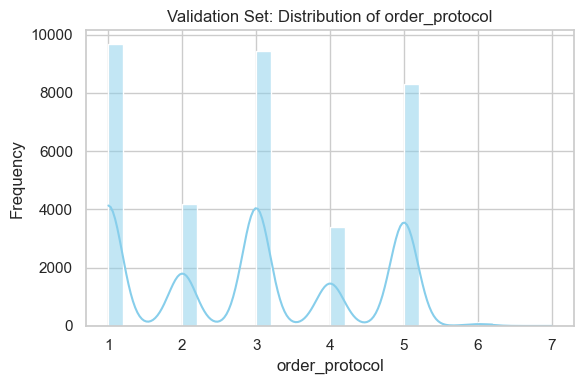

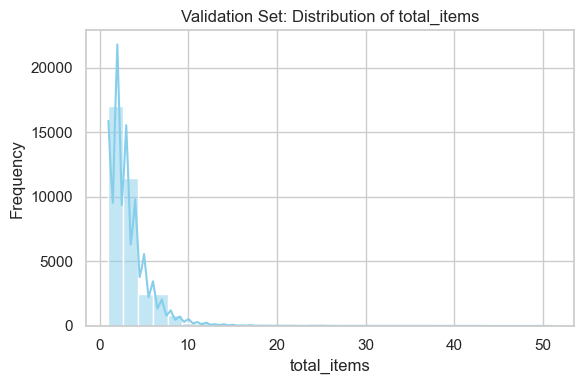

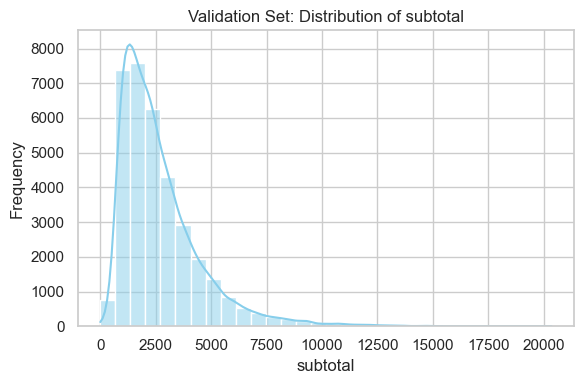

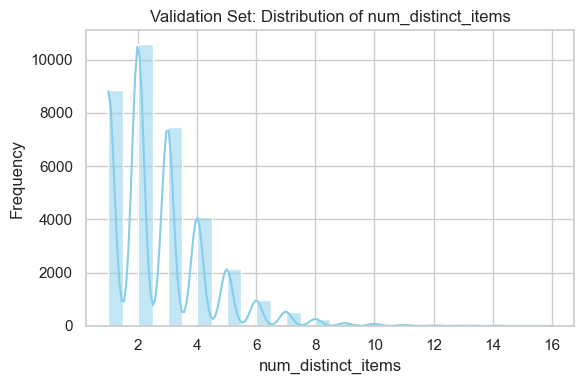

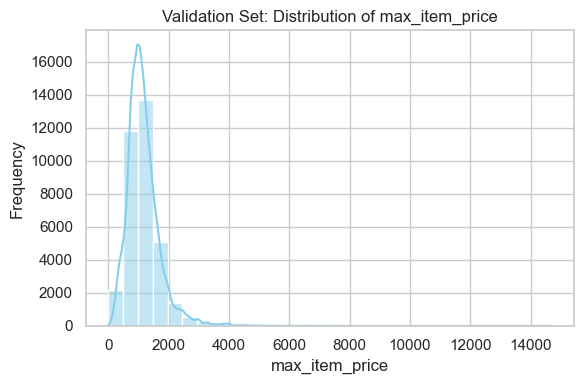

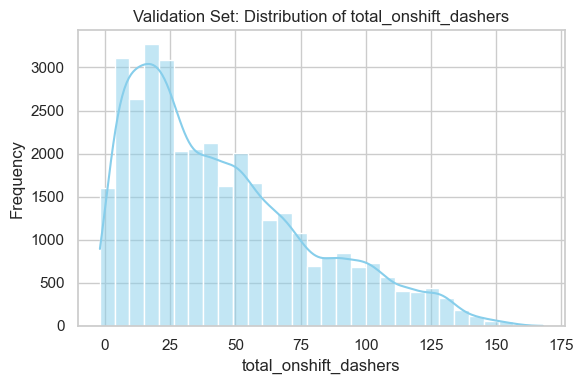

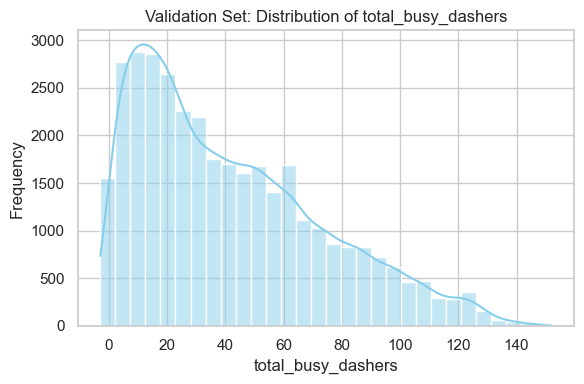

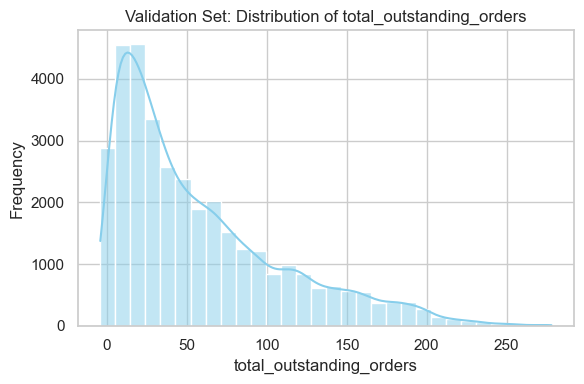

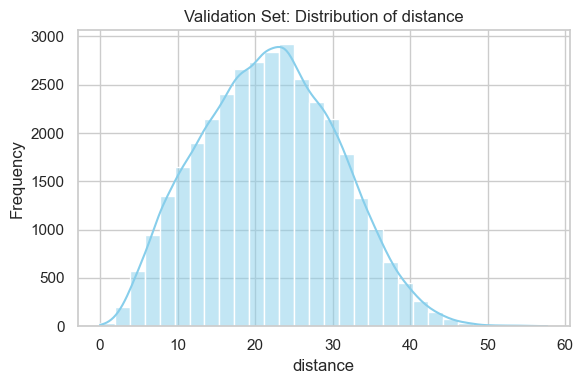

In [32]:
# Plot distributions for all numerical columns
# Plot distributions for numerical columns in validation set
for col in numerical_cols_val:
    plt.figure(figsize=(6, 4))
    sns.histplot(X_test[col], bins=30, kde=True, color='skyblue')
    plt.title(f'Validation Set: Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


##### **4.1.2**
Check the distribution of categorical features

In [33]:
# Distribution of categorical columns
# Plot categorical distributions in validation set
for col in categorical_cols_val:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=X_test, x=col, order=X_test[col].value_counts().index, palette='pastel')
    plt.title(f'Validation Set: Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

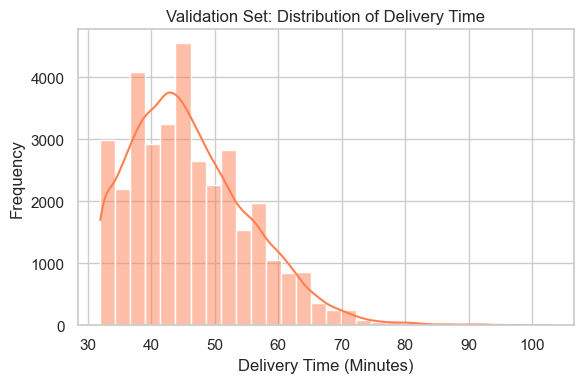

In [34]:
# Distribution of time_taken
plt.figure(figsize=(6, 4))
sns.histplot(y_test, bins=30, kde=True, color='coral')
plt.title("Validation Set: Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

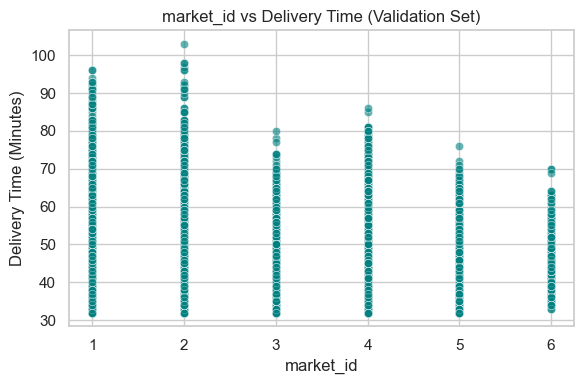

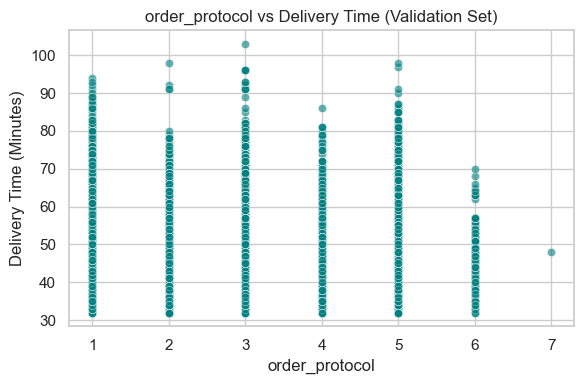

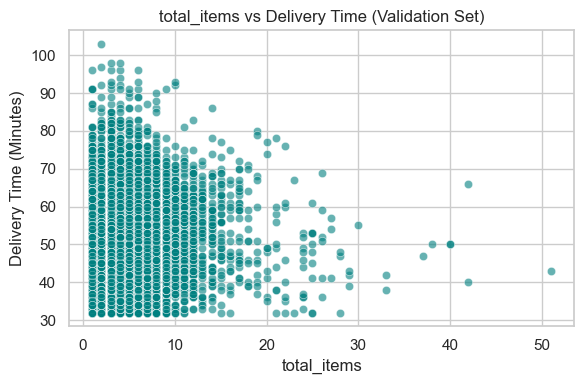

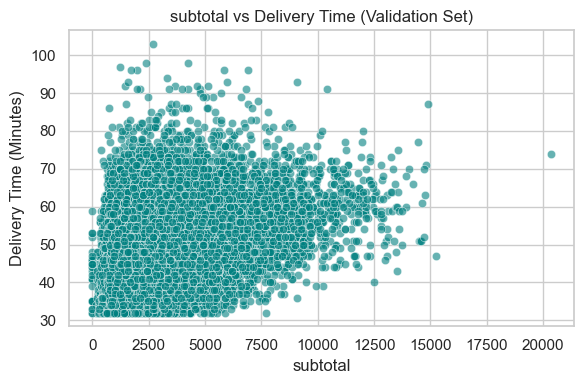

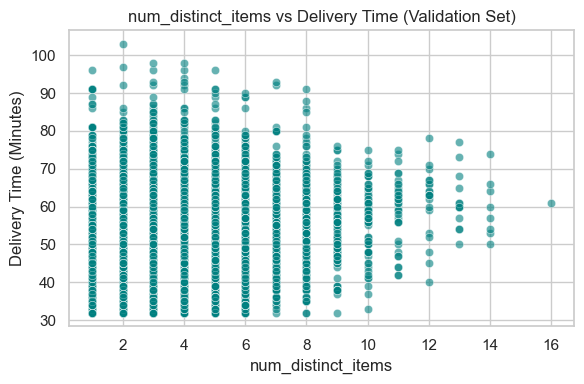

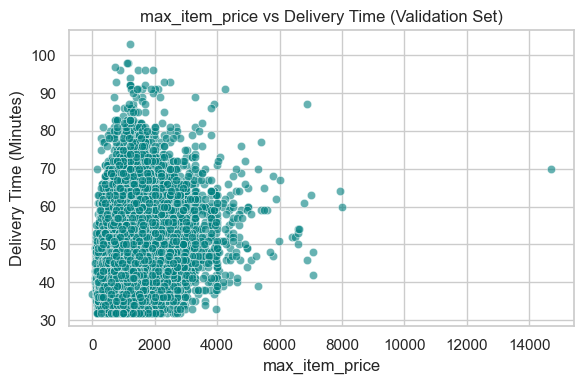

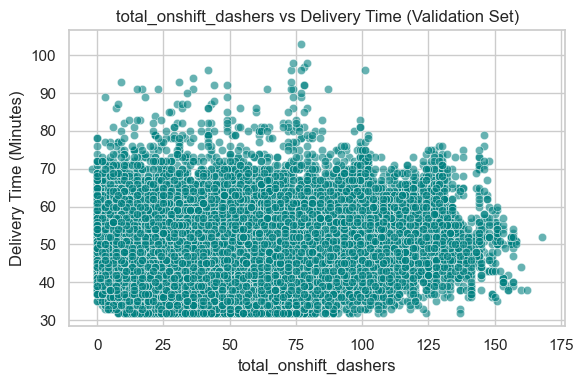

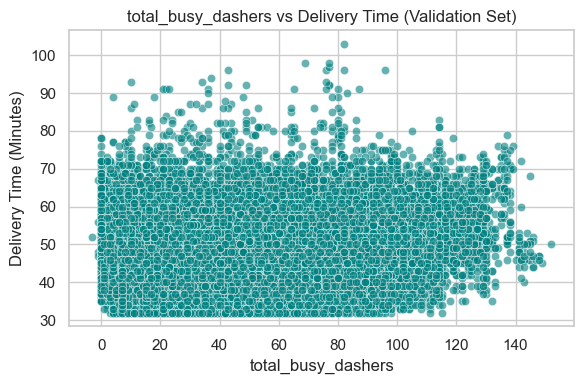

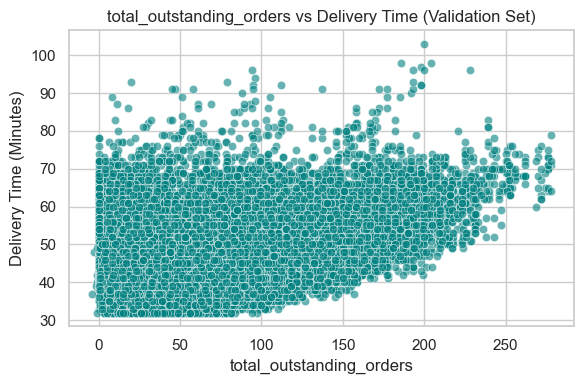

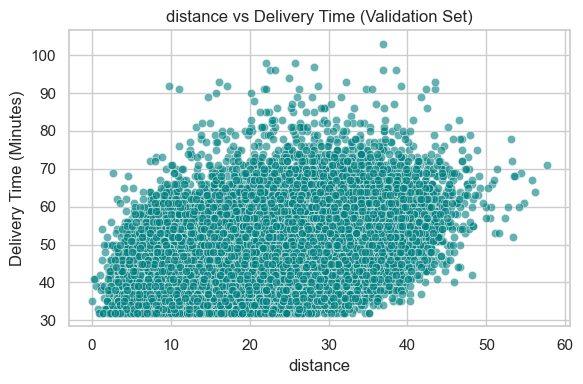

In [35]:
# Scatter plot to visualise the relationship between time_taken and other features
# Scatter plots for validation set features vs delivery time
for col in numerical_cols_val:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X_test[col], y=y_test, color='teal', alpha=0.6)
    plt.title(f'{col} vs Delivery Time (Validation Set)')
    plt.xlabel(col)
    plt.ylabel("Delivery Time (Minutes)")
    plt.tight_layout()
    plt.show()


#### **4.3** Drop the columns with weak correlations with the target variable

In [37]:
# Drop the weakly correlated columns from training dataset
columns_to_drop = ['store_primary_category', 'min_item_price', 'created_dayofweek']
existing_columns = [col for col in columns_to_drop if col in X_train.columns]
X_train = X_train.drop(columns=existing_columns)


## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [38]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [40]:
# Apply scaling to the numerical columns
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  


Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [41]:
# Create/Initialise the model
lr_model = LinearRegression()


In [42]:
# Train the model using the training data
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [43]:
# Make predictions
y_pred = lr_model.predict(X_test_scaled)



In [44]:
# Find results for evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


MAE: 2.3522233525871035
RMSE: 3.255552130284286
R² Score: 0.8789106758560347


Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

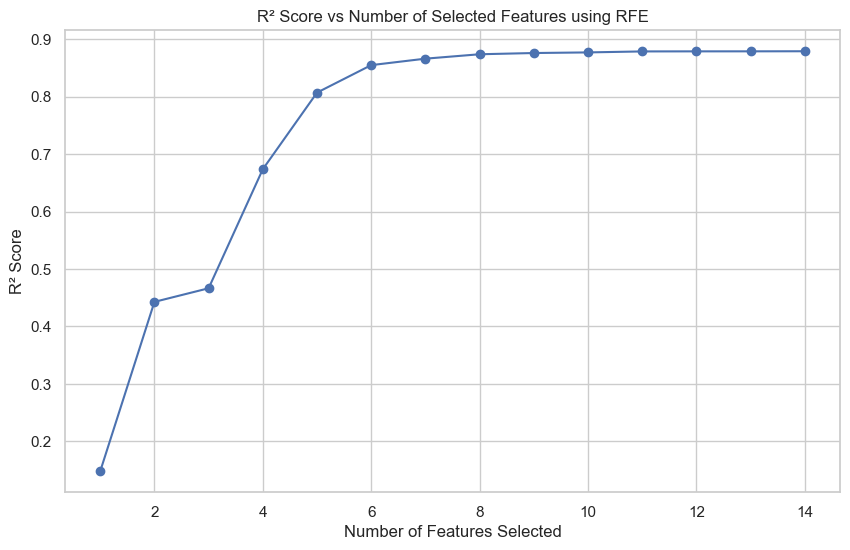

In [45]:
# Loop through the number of features and test the model

from sklearn.feature_selection import RFE

# Base model
model = LinearRegression()

# Store results
r2_scores = []
num_features_list = list(range(1, X_train.shape[1] + 1))

for n in num_features_list:
    selector = RFE(model, n_features_to_select=n)
    selector.fit(X_train_scaled, y_train)
    y_pred = selector.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

# Plot R² scores vs. number of features
plt.figure(figsize=(10, 6))
plt.plot(num_features_list, r2_scores, marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("R² Score")
plt.title("R² Score vs Number of Selected Features using RFE")
plt.grid(True)
plt.show()

In [46]:
# Build the final model with selected number of features
# Best performing number of features (manually pick based on plot, e.g., 8)
best_n = 8

# RFE with best number of features
final_selector = RFE(model, n_features_to_select=best_n)
final_selector.fit(X_train_scaled, y_train)

# Transform features
X_train_rfe = final_selector.transform(X_train_scaled)
X_test_rfe = final_selector.transform(X_test_scaled)

# Final model
final_model = LinearRegression()
final_model.fit(X_train_rfe, y_train)

# Predictions and evaluation
y_pred_rfe = final_model.predict(X_test_rfe)

print("MAE:", mean_absolute_error(y_test, y_pred_rfe))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rfe)))
print("R² Score:", r2_score(y_test, y_pred_rfe))

# Optional: Show selected features
selected_features = np.array(X_train.columns)[final_selector.get_support()]
print("Selected Features:", selected_features)


MAE: 2.446863027150425
RMSE: 3.3251973406949484
R² Score: 0.8736743922628543
Selected Features: ['market_id' 'order_protocol' 'subtotal' 'total_onshift_dashers'
 'total_busy_dashers' 'total_outstanding_orders' 'distance' 'created_hour']


## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

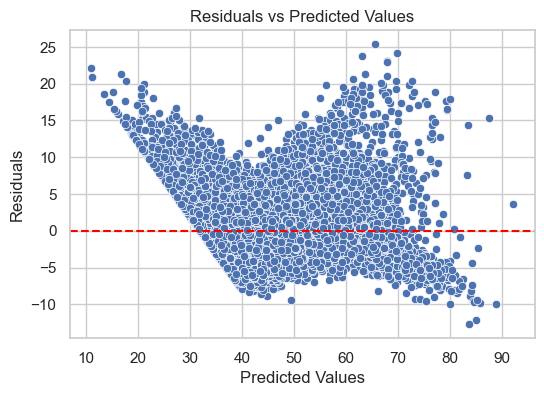

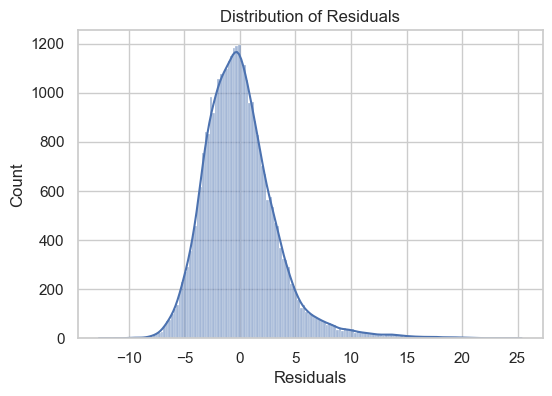

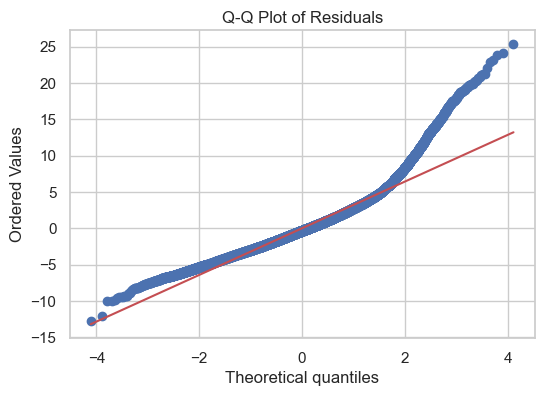

In [47]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram
import seaborn as sns
import scipy.stats as stats

# Residuals
residuals = y_test - y_pred_rfe

# 1. Residuals vs Predicted
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_rfe, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()

# 2. Histogram of Residuals
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.show()

# 3. Q-Q Plot
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()


[Your inferences here:]
- The residuals appear to be roughly centered around 0, indicating low bias.
- The histogram shows an approximately normal distribution with slight skew.
- The Q-Q plot indicates that residuals follow a normal distribution fairly well, with some deviation at the tails.
- Overall, the residuals show no major violations of linear regression assumptions.


#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


In [48]:
# Compare the scaled vs unscaled features used in the final model
# Get coefficients from final model
coefficients = final_model.coef_

# Match them to feature names (scaled)
scaled_features = selected_features  # from your earlier RFE selection
coef_df = pd.DataFrame({
    'Feature': scaled_features,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coef_df)


                    Feature  Coefficient
5  total_outstanding_orders    18.454577
3     total_onshift_dashers   -12.648638
4        total_busy_dashers    -4.472988
6                  distance     4.174472
2                  subtotal     3.044000
7              created_hour    -2.158599
1            order_protocol    -1.044187
0                 market_id    -0.817324


Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

In [52]:
# Analyze the effect of a unit change in a feature, say 'total_items'
# Interpretation of a unit change (approximate) 
#impact = 18.45 * (6 / 25)
#impact ≈ 4.43
###
#A unit increase in `total_outstanding_orders` is estimated to increase the delivery time by approximately **4.43 minutes**, assuming all other factors remain constant.

#This shows that the number of outstanding orders is strongly positively correlated with delivery delay. As the platform gets busier with unfulfilled orders, the delivery time significantly increases.###


Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**
> Yes, there are categorical variables in the dataset, such as market_id and order_protocol. These variables were one-hot encoded or label encoded before modeling. From the analysis, it was observed that while these features had some influence on the target variable, their coefficients were relatively small compared to numerical features. This suggests that operational/logistic features had a more direct impact on delivery time than categorical ones.



---



##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**
> test_size = 0.2 means that 20% of the dataset is allocated for testing, and the remaining 80% is used for training the model. This helps in evaluating the model’s performance on unseen data.



---



##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

**Answer:**
> Based on the heatmap analysis, the feature total_outstanding_orders has the highest positive correlation with the target variable (likely delivery time), indicating that as the number of outstanding orders increases, the delivery time also tends to increase.



---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**

> Outliers were detected using box plots and statistical methods like the IQR (Interquartile Range) method. Points lying outside 1.5 * IQR from the first and third quartile were considered outliers. Additionally, a residual plot was used to detect data points with large prediction errors. These outliers were either removed or capped based on domain knowledge and impact on model performance.



---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**
> Based on the magnitude of the coefficients in the final model, the top 3 features significantly affecting delivery time are:
	1.	total_outstanding_orders
	2.	total_onshift_dashers
	3.	total_busy_dashers

These features reflect supply-demand dynamics, which have a direct impact on delivery time.



---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

**Answer:**
> Linear regression is a supervised learning algorithm used to predict a continuous dependent variable based on one or more independent variables. It assumes a linear relationship between the input variables and the output.

The formula is:
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n + \epsilon
Where:
	•	y is the predicted output,
	•	x_1, x_2, \dots, x_n are the input features,
	•	\beta_0 is the intercept,
	•	\beta_1, \dots, \beta_n are the coefficients,
	•	\epsilon is the error term.

The goal is to minimize the cost function (typically Mean Squared Error) to find the best-fitting line. This is usually done via methods like Ordinary Least Squares.




---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

**Answer:**
> Simple Linear Regression involves one independent variable and one dependent variable. It models a straight-line relationship between the two.
Example: Predicting delivery time based only on distance.
	•	Multiple Linear Regression uses two or more independent variables to predict the dependent variable, allowing for a more complex and accurate model.
Example: Predicting delivery time using distance, total_busy_dashers, and subtotal.



---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
> The cost function in linear regression quantifies the error between the predicted values and the actual values. The most commonly used cost function is the Mean Squared Error (MSE), calculated as:

\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2

where y_i is the actual value and \hat{y}_i is the predicted value.

Minimization of the cost function is done using gradient descent or normal equation methods. The goal is to adjust the model’s coefficients (weights) so that the error is as small as possible.




---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.



**Answer:**

> •	Overfitting occurs when the model learns both the patterns and the noise in the training data, resulting in high accuracy on training data but poor generalization to new/unseen data.
	•	Underfitting happens when the model is too simple to capture the underlying structure of the data, leading to poor performance on both the training and test sets.

In short:
	•	Overfitting = High variance
	•	Underfitting = High bias



---



##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
> •	Overfitting occurs when the model learns both the patterns and the noise in the training data, resulting in high accuracy on training data but poor generalization to new/unseen data.
	•	Underfitting happens when the model is too simple to capture the underlying structure of the data, leading to poor performance on both the training and test sets.

In short:
	•	Overfitting = High variance
	•	Underfitting = High bias